# Traffic Accident Analysis

This notebook explores traffic accident data to answer practical questions about when, where, and under what conditions accidents happen.


In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "data").exists() and (parent / "src").exists():
            PROJECT_ROOT = parent
            break

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from traffic_analysis import (
    clean_column_names,
    find_column,
    find_first_dataset,
    load_dataset,
    plot_top_categories,
    summarize_dataframe,
)

print(f"Python: {sys.executable}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder: {DATA_DIR}")

Python: c:\Users\abhia\Desktop\project_2\traffic_accident_project\.venv\Scripts\python.exe
Project root: C:\Users\abhia\Desktop\project_2\traffic_accident_project
Data folder: C:\Users\abhia\Desktop\project_2\traffic_accident_project\data


In [4]:
raw_df = None
data_path = None

try:
    data_path = find_first_dataset(DATA_DIR)
    raw_df = load_dataset(data_path)
    print(f"Loaded: {data_path.name}")
    print(f"Rows: {raw_df.shape[0]:,}")
    print(f"Columns: {raw_df.shape[1]:,}")
    display(raw_df.head())
except FileNotFoundError as error:
    print(error)

Loaded: cleaned_accidents.csv
Rows: 50,000
Columns: 33


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,cross_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5,accident_datetime,hour,day_name,month
0,2026-05-19T00:00:00.000,16:30,QUEENS,11429.0,40.713580,-73.737290,"\n, \n(40.71358, -73.73729)",NaN,NaN,218-24 HEMPSTEAD AVE,1,NaN,0,0,0,0,1,0,Passing or Lane Usage Improper,Unspecified,NaN,NaN,NaN,4900037,4 dr sedan,4 dr sedan,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
1,2026-05-19T00:00:00.000,21:02,MANHATTAN,10018.0,40.756380,-73.990650,"\n, \n(40.75638, -73.99065)",NaN,NaN,625 8 AVE,0,NaN,0,0,0,0,0,0,36,Unspecified,NaN,NaN,NaN,4900011,2 dr sedan,NaN,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
2,2026-05-19T00:00:00.000,16:33,BROOKLYN,11238.0,40.684593,-73.970160,"\n, \n(40.684593, -73.97016)",FULTON ST,ADELPHI ST,NaN,0,NaN,0,0,0,0,0,0,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,NaN,NaN,NaN,4900086,BICY,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
3,2026-05-19T00:00:00.000,13:00,BROOKLYN,11206.0,40.711643,-73.943910,"\n, \n(40.711643, -73.94391)",GRAND ST,GRAHAM AVE,NaN,1,NaN,0,0,1,0,0,0,Failure to Yield Right-of-Way,Unspecified,NaN,NaN,NaN,4900487,4 dr sedan,BICY,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
4,2026-05-19T00:00:00.000,5:53,QUEENS,11354.0,40.762420,-73.827515,"\n, \n(40.76242, -73.827515)",UNION ST,37 AVE,NaN,1,NaN,0,0,0,0,1,0,Fell Asleep,Unspecified,NaN,NaN,NaN,4900056,4 dr sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,2026-05-19,0,Tuesday,May


In [5]:
df = None

if raw_df is None:
    print("Add a dataset to the data folder, then rerun the load cell.")
else:
    df = clean_column_names(raw_df)
    print(f"Cleaned shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    display(df.head())

Cleaned shape: 50,000 rows x 33 columns


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,cross_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5,accident_datetime,hour,day_name,month
0,2026-05-19T00:00:00.000,16:30,QUEENS,11429.0,40.713580,-73.737290,"\n, \n(40.71358, -73.73729)",NaN,NaN,218-24 HEMPSTEAD AVE,1,NaN,0,0,0,0,1,0,Passing or Lane Usage Improper,Unspecified,NaN,NaN,NaN,4900037,4 dr sedan,4 dr sedan,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
1,2026-05-19T00:00:00.000,21:02,MANHATTAN,10018.0,40.756380,-73.990650,"\n, \n(40.75638, -73.99065)",NaN,NaN,625 8 AVE,0,NaN,0,0,0,0,0,0,36,Unspecified,NaN,NaN,NaN,4900011,2 dr sedan,NaN,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
2,2026-05-19T00:00:00.000,16:33,BROOKLYN,11238.0,40.684593,-73.970160,"\n, \n(40.684593, -73.97016)",FULTON ST,ADELPHI ST,NaN,0,NaN,0,0,0,0,0,0,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,NaN,NaN,NaN,4900086,BICY,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
3,2026-05-19T00:00:00.000,13:00,BROOKLYN,11206.0,40.711643,-73.943910,"\n, \n(40.711643, -73.94391)",GRAND ST,GRAHAM AVE,NaN,1,NaN,0,0,1,0,0,0,Failure to Yield Right-of-Way,Unspecified,NaN,NaN,NaN,4900487,4 dr sedan,BICY,NaN,NaN,NaN,2026-05-19,0,Tuesday,May
4,2026-05-19T00:00:00.000,5:53,QUEENS,11354.0,40.762420,-73.827515,"\n, \n(40.76242, -73.827515)",UNION ST,37 AVE,NaN,1,NaN,0,0,0,0,1,0,Fell Asleep,Unspecified,NaN,NaN,NaN,4900056,4 dr sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,2026-05-19,0,Tuesday,May


In [6]:
summary = None

if df is None:
    print("Load and clean a dataset first.")
else:
    summary = summarize_dataframe(df)
    display(summary)

,dtype,non_null,missing,missing_pct,unique
vehicle_type_code_5,str,252,49748,99.50,14
contributing_factor_vehicle_5,str,260,49740,99.48,7
vehicle_type_code_4,str,900,49100,98.20,29
contributing_factor_vehicle_4,str,956,49044,98.09,10
vehicle_type_code_3,str,3498,46502,93.00,66
contributing_factor_vehicle_3,str,3800,46200,92.40,29
cross_street_name,str,15754,34246,68.49,14379
off_street_name,str,28126,21874,43.75,4135
vehicle_type_code2,str,31773,18227,36.45,307
on_street_name,str,34246,15754,31.51,3673


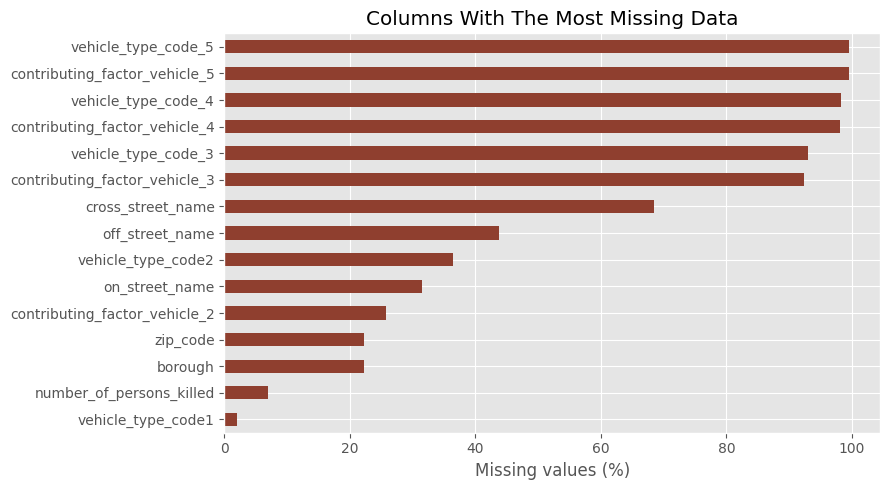

In [7]:
if summary is None:
    print("No summary available yet.")
else:
    missing = summary.query("missing > 0").sort_values("missing_pct", ascending=False).head(15)

    if missing.empty:
        print("No missing values found.")
    else:
        ax = missing.sort_values("missing_pct")["missing_pct"].plot(
            kind="barh", figsize=(9, 5), color="#8f3f2f"
        )
        ax.set_title("Columns With The Most Missing Data")
        ax.set_xlabel("Missing values (%)")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()

In [8]:
column_candidates = {}

if df is None:
    print("Load a dataset first.")
else:
    column_candidates = {
        "date_or_time": find_column(df, [
            "start_time", "accident_date", "crash_date", "date", "datetime", "timestamp", "time"
        ]),
        "severity": find_column(df, [
            "severity", "crash_severity", "accident_severity", "injury_severity", "severity_description"
        ]),
        "city": find_column(df, ["city", "town", "municipality"]),
        "county": find_column(df, ["county", "county_name"]),
        "state": find_column(df, ["state", "state_name", "province"]),
        "weather": find_column(df, ["weather", "weather_condition", "weather_conditions"]),
        "road_condition": find_column(df, [
            "road_condition", "road_conditions", "road_surface_condition", "surface_condition"
        ]),
        "lighting": find_column(df, [
            "lighting", "light_condition", "light_conditions", "lighting_condition"
        ]),
    }

    display(
        pd.DataFrame(
            [{"analysis_area": key, "detected_column": value} for key, value in column_candidates.items()]
        )
    )

,analysis_area,detected_column
0,date_or_time,crash_date
1,severity,NaN
2,city,NaN
3,county,NaN
4,state,NaN
5,weather,NaN
6,road_condition,NaN
7,lighting,NaN


In [9]:
if df is None:
    print("Load a dataset first.")
else:
    date_col = column_candidates.get("date_or_time")

    if date_col is None:
        print("No date/time column was detected. Update the candidate list if your dataset has one.")
    else:
        df["accident_datetime"] = pd.to_datetime(df[date_col], errors="coerce")
        df["hour"] = df["accident_datetime"].dt.hour
        df["day_name"] = df["accident_datetime"].dt.day_name()
        df["month"] = df["accident_datetime"].dt.month_name()

        print(f"Parsed date/time from: {date_col}")
        display(df[[date_col, "accident_datetime", "hour", "day_name", "month"]].head())

Parsed date/time from: crash_date


,crash_date,accident_datetime,hour,day_name,month
0,2026-05-19T00:00:00.000,2026-05-19,0,Tuesday,May
1,2026-05-19T00:00:00.000,2026-05-19,0,Tuesday,May
2,2026-05-19T00:00:00.000,2026-05-19,0,Tuesday,May
3,2026-05-19T00:00:00.000,2026-05-19,0,Tuesday,May
4,2026-05-19T00:00:00.000,2026-05-19,0,Tuesday,May


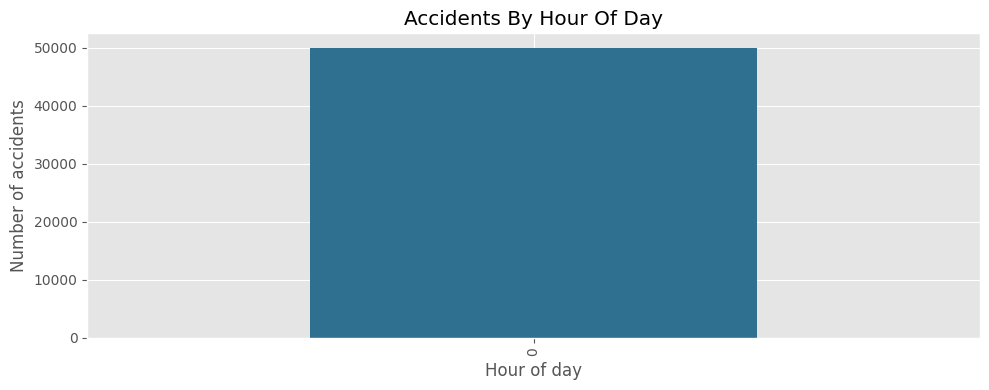

In [10]:
if df is None or "hour" not in df.columns:
    print("No hourly time feature available yet.")
else:
    hourly = df["hour"].dropna().astype(int).value_counts().sort_index()

    ax = hourly.plot(kind="bar", figsize=(10, 4), color="#2f6f8f")
    ax.set_title("Accidents By Hour Of Day")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Number of accidents")
    plt.tight_layout()
    plt.show()

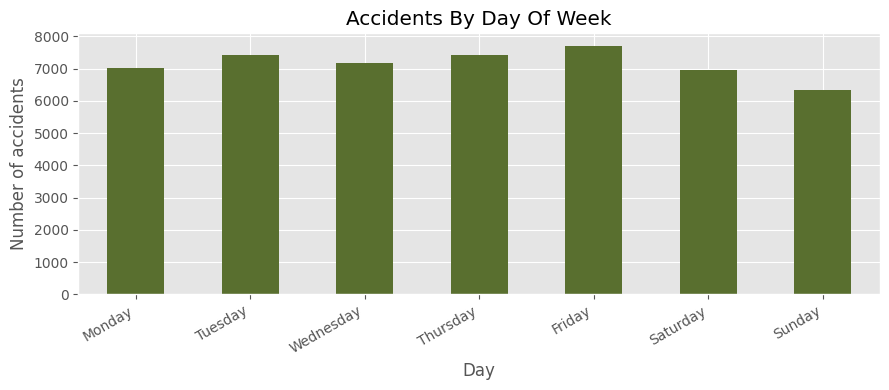

In [11]:
if df is None or "day_name" not in df.columns:
    print("No day-of-week feature available yet.")
else:
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    day_counts = df["day_name"].value_counts().reindex(day_order).dropna()

    ax = day_counts.plot(kind="bar", figsize=(9, 4), color="#596f2f")
    ax.set_title("Accidents By Day Of Week")
    ax.set_xlabel("Day")
    ax.set_ylabel("Number of accidents")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [12]:
if df is None:
    print("Load a dataset first.")
else:
    severity_col = column_candidates.get("severity")

    if severity_col is None:
        print("No severity column was detected.")
    else:
        plot_top_categories(df, severity_col, top_n=10, title="Accidents By Severity")
        plt.show()

No severity column was detected.


In [13]:
if df is None:
    print("Load a dataset first.")
else:
    location_col = column_candidates.get("city") or column_candidates.get("county") or column_candidates.get("state")

    if location_col is None:
        print("No city, county, or state column was detected.")
    else:
        plot_top_categories(df, location_col, top_n=15, title=f"Top Accident Locations By {location_col}")
        plt.show()

No city, county, or state column was detected.


In [14]:
if df is None:
    print("Load a dataset first.")
else:
    for key, title in [
        ("weather", "Accidents By Weather Condition"),
        ("road_condition", "Accidents By Road Condition"),
        ("lighting", "Accidents By Lighting Condition"),
    ]:
        column = column_candidates.get(key)
        if column is None:
            print(f"No detected column for {key}.")
            continue

        plot_top_categories(df, column, top_n=10, title=title)
        plt.show()

No detected column for weather.
No detected column for road_condition.
No detected column for lighting.


In [15]:
if df is None:
    print("Load a dataset first.")
else:
    numeric_df = df.select_dtypes(include="number")

    if numeric_df.empty:
        print("No numeric columns found.")
    else:
        display(numeric_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
zip_code,38854.0,1.087377e+04,535.011917,1.000000e+04,1.045300e+04,1.120800e+04,1.123600e+04,1.234500e+04
latitude,49522.0,3.980729e+01,6.036567,0.000000e+00,4.066251e+01,4.071373e+01,4.077104e+01,4.091208e+01
longitude,49522.0,-7.225710e+01,10.956790,-7.425297e+01,-7.396930e+01,-7.392049e+01,-7.385860e+01,0.000000e+00
number_of_persons_injured,50000.0,5.593600e-01,0.834847,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+01
number_of_persons_killed,46511.0,2.322031e-03,0.049017,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
number_of_pedestrians_injured,50000.0,1.140800e-01,0.333569,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00
number_of_pedestrians_killed,50000.0,1.340000e-03,0.037125,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
number_of_cyclist_injured,50000.0,5.178000e-02,0.226318,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
number_of_cyclist_killed,50000.0,2.600000e-04,0.016123,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
number_of_motorist_injured,50000.0,3.806600e-01,0.814501,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+01


In [16]:
if df is None:
    print("Load and clean a dataset before saving.")
else:
    cleaned_path = DATA_DIR / "cleaned_accidents.csv"
    df.to_csv(cleaned_path, index=False)
    print(f"Saved cleaned data to: {cleaned_path}")

Saved cleaned data to: C:\Users\abhia\Desktop\project_2\traffic_accident_project\data\cleaned_accidents.csv
